<H1>RFM Analysis</H1>

In [4]:
import pandas as pd
from google.cloud import bigquery
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [5]:
path_ke_key = os.path.join('..','..', 'bq_key', 'my_dbt_key.json')

os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = path_ke_key

client = bigquery.Client()

query = """
    SELECT 
        fs.customer_sk, 
        dd.full_date, 
        fs.order_revenue, 
        fs.order_freight_value
    FROM `dbt-project-482716.dbt_dataset_global.fact_sales` fs
    JOIN `dbt-project-482716.dbt_dataset_global.dim_date` dd
        ON fs.purchase_date_sk = dd.date_sk
    WHERE fs.order_status = 'delivered'
"""

In [6]:
df_orders = client.query(query).to_dataframe()

print(df_orders.head())

/opt/anaconda3/envs/bq_env/lib/python3.11/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


                        customer_sk   full_date  order_revenue  \
0  4b8ae60e4bd0512b27cfd71253443d54  2016-09-15         134.97   
1  eeb8f64fe36c349911ce1cb6618dd75a  2016-10-03          29.90   
2  93830549c9d2708f8e903f7c1a4eebbe  2016-10-03          21.90   
3  ce9145ff1bf58b1eb7d78d8fe430a5b6  2016-10-04         119.90   
4  17d48eb0a27b4f11377e26a257a2dbde  2016-10-04          29.99   

   order_freight_value  
0                 8.49  
1                15.56  
2                17.19  
3                13.56  
4                10.96  


In [7]:
df_orders['full_date'] = pd.to_datetime(df_orders['full_date'])

snapshot_date = df_orders['full_date'].max() + pd.Timedelta(days=1)

In [8]:
df_orders['total_order_value'] = df_orders['order_revenue'] + df_orders['order_freight_value']


rfm_df = df_orders.groupby('customer_sk').agg(
    Recency=('full_date', lambda x: (snapshot_date - x.max()).days),
    Frequency=('full_date', 'count'),
    Monetary=('total_order_value', 'sum')
)

# Cek hasilnya
print(rfm_df.head())

                                  Recency  Frequency  Monetary
customer_sk                                                   
00008a3950b10408b6a8584331bdf4e1      421          1    557.62
0000bd96c81b8190e737c54bd1fa6fe8      376          1     91.66
0003107ee32dee7d9877211ffdd40f58       15          1     45.30
000495312061c85f492bcb30dd3d643b      226          1    103.83
0004b75cd362e2c0971a1fab3918bfa5       22          1    145.07


In [9]:
print(rfm_df['Frequency'].value_counts())

Frequency
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
15        1
9         1
Name: count, dtype: int64


In [10]:
rfm_log = np.log(rfm_df + 1)

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled = pd.DataFrame(rfm_scaled, index=rfm_df.index, columns=rfm_df.columns)

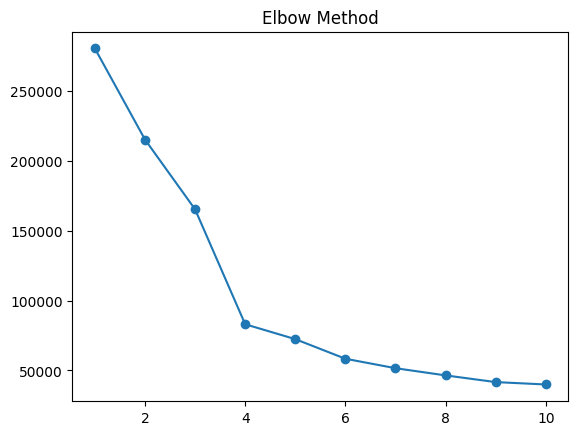

In [11]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.show()

In [12]:
k = 4
model = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
rfm_df['cluster'] = model.fit_predict(rfm_scaled)


In [13]:
cluster_profile = rfm_df.groupby('cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'cluster': 'count'
}).rename(columns={'cluster': 'Total_Customers'}).round(2)

print("=== Cluster Profile ===")
print(cluster_profile)

=== Cluster Profile ===
         Recency  Frequency  Monetary  Total_Customers
cluster                                               
0         288.00       1.00     70.12            42621
1         272.71       1.00    315.59            31686
2          42.62       1.00    136.38            16250
3         220.42       2.11    324.72             2801


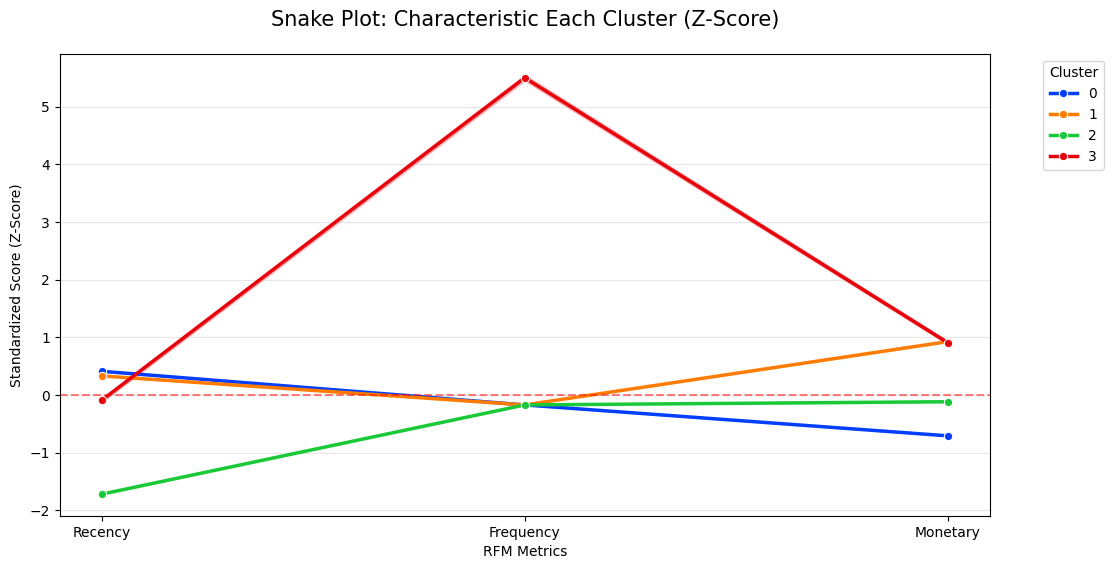

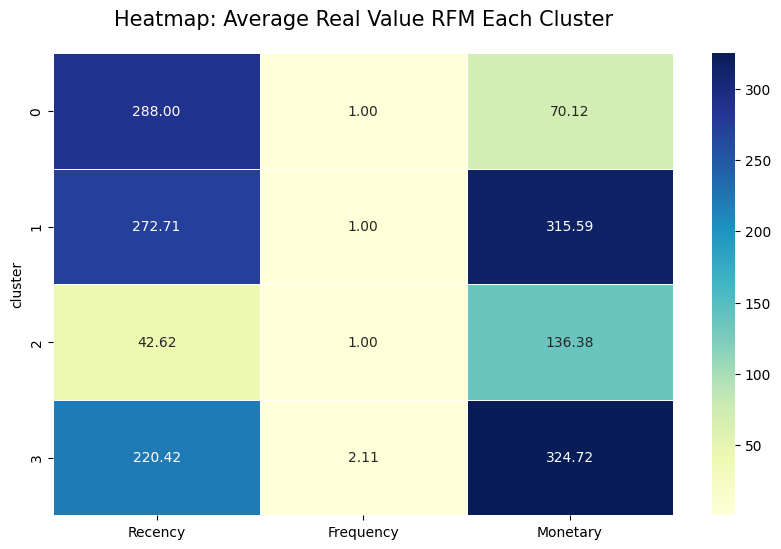

In [14]:
rfm_scaled['cluster'] = rfm_df['cluster'].values
rfm_scaled['customer_sk'] = rfm_df.index  

rfm_melted = pd.melt(rfm_scaled, 
                    id_vars=['customer_sk', 'cluster'],
                    value_vars=['Recency', 'Frequency', 'Monetary'], 
                    var_name='Metric', 
                    value_name='Value')

# --- SNAKE PLOT ---
plt.figure(figsize=(12, 6))
sns.lineplot(data=rfm_melted, x='Metric', y='Value', hue='cluster', palette='bright', marker='o', linewidth=2.5)

plt.axhline(0, color='red', linestyle='--', alpha=0.5)

plt.title('Snake Plot: Characteristic Each Cluster (Z-Score)', fontsize=15, pad=20)
plt.ylabel('Standardized Score (Z-Score)')
plt.xlabel('RFM Metrics')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

# --- 3. HEATMAP PROFILING ---
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profile[['Recency', 'Frequency', 'Monetary']], 
            annot=True, 
            cmap='YlGnBu', 
            fmt='.2f', 
            linewidths=.5)

plt.title('Heatmap: Average Real Value RFM Each Cluster', fontsize=15, pad=20)
plt.show()

In [15]:
segment_map = {
    2: 'New Customers',
    3: 'Champions',
    1: 'Big Spenders at Risk',
    0: 'Hibernating'
}

rfm_df['Segment'] = rfm_df['cluster'].map(segment_map)

print(rfm_df[['Recency', 'Frequency', 'Monetary', 'Segment']].head())

                                  Recency  Frequency  Monetary  \
customer_sk                                                      
00008a3950b10408b6a8584331bdf4e1      421          1    557.62   
0000bd96c81b8190e737c54bd1fa6fe8      376          1     91.66   
0003107ee32dee7d9877211ffdd40f58       15          1     45.30   
000495312061c85f492bcb30dd3d643b      226          1    103.83   
0004b75cd362e2c0971a1fab3918bfa5       22          1    145.07   

                                               Segment  
customer_sk                                             
00008a3950b10408b6a8584331bdf4e1  Big Spenders at Risk  
0000bd96c81b8190e737c54bd1fa6fe8           Hibernating  
0003107ee32dee7d9877211ffdd40f58         New Customers  
000495312061c85f492bcb30dd3d643b           Hibernating  
0004b75cd362e2c0971a1fab3918bfa5         New Customers  


In [16]:
rfm_df

,Recency,Frequency,Monetary,cluster,Segment
customer_sk,,,,,
00008a3950b10408b6a8584331bdf4e1,421,1,557.62,1,Big Spenders at Risk
0000bd96c81b8190e737c54bd1fa6fe8,376,1,91.66,0,Hibernating
0003107ee32dee7d9877211ffdd40f58,15,1,45.30,2,New Customers
000495312061c85f492bcb30dd3d643b,226,1,103.83,0,Hibernating
0004b75cd362e2c0971a1fab3918bfa5,22,1,145.07,2,New Customers
...,...,...,...,...,...
fffefa6f9346d31bc003e730e149ff91,136,1,73.05,0,Hibernating
ffff2fef570fe4637be30be51ff4f7a4,469,1,144.34,1,Big Spenders at Risk
ffff4585d3179792edb070b7a850e5de,125,1,79.79,0,Hibernating


<H1>CLV Analysis</H1>

In [19]:
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data

In [20]:
clv_df = summary_data_from_transaction_data(
    df_orders, 
    customer_id_col='customer_sk', 
    datetime_col='full_date', 
    monetary_value_col='total_order_value',
    observation_period_end=df_orders['full_date'].max()
)

In [21]:
clv_df = clv_df[clv_df['frequency'] > 0]

bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(clv_df['frequency'], clv_df['recency'], clv_df['T'])

ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(clv_df['frequency'], clv_df['monetary_value'])

clv_df['predicted_clv'] = ggf.customer_lifetime_value(
    bgf,
    clv_df['frequency'],
    clv_df['recency'],
    clv_df['T'],
    clv_df['monetary_value'],
    time=6,
    discount_rate=0.01
)

In [22]:
# average_cac = 50000 

# clv_df['clv_cac_ratio'] = clv_df['predicted_clv'] / average_cac

# def marketing_efficiency(ratio):
#     if ratio > 3:
#         return 'Scale Up'
#     elif ratio >= 1:
#         return 'Optimization'
#     else:
#         return 'Evaluation'

# clv_df['strategy_action'] = clv_df['clv_cac_ratio'].apply(marketing_efficiency)

# print(clv_df[['predicted_clv', 'clv_cac_ratio', 'strategy_action']].head())

In [23]:
clv_df['Badge'] = pd.qcut(clv_df['predicted_clv'], 
                         q=[0, 0.4, 0.75, 0.9, 1], 
                         labels=['Bronze', 'Silver', 'Gold', 'Platinum'])

In [24]:
rfm_df

,Recency,Frequency,Monetary,cluster,Segment
customer_sk,,,,,
00008a3950b10408b6a8584331bdf4e1,421,1,557.62,1,Big Spenders at Risk
0000bd96c81b8190e737c54bd1fa6fe8,376,1,91.66,0,Hibernating
0003107ee32dee7d9877211ffdd40f58,15,1,45.30,2,New Customers
000495312061c85f492bcb30dd3d643b,226,1,103.83,0,Hibernating
0004b75cd362e2c0971a1fab3918bfa5,22,1,145.07,2,New Customers
...,...,...,...,...,...
fffefa6f9346d31bc003e730e149ff91,136,1,73.05,0,Hibernating
ffff2fef570fe4637be30be51ff4f7a4,469,1,144.34,1,Big Spenders at Risk
ffff4585d3179792edb070b7a850e5de,125,1,79.79,0,Hibernating


<H1>Export Seeds</H1>

In [25]:
rfm_df_ready = rfm_df.reset_index()
clv_df_ready = clv_df.reset_index()
rfm_df_ready['customer_sk'] = rfm_df_ready['customer_sk'].astype(str)
clv_df_ready['customer_sk'] = clv_df_ready['customer_sk'].astype(str)

final_seeds = pd.merge(
    rfm_df_ready[['customer_sk', 'Recency', 'Frequency', 'Monetary', 'Segment']], 
    clv_df_ready[['customer_sk', 'predicted_clv', 'Badge']], 
    on='customer_sk',
    how='left'
)

In [26]:
final_seeds['predicted_clv'] = final_seeds['predicted_clv'].fillna(0)

final_seeds['Badge'] = final_seeds['Badge'].astype(str)
final_seeds['Badge'] = final_seeds['Badge'].fillna('One Time Buyer')
final_seeds['Badge'] = final_seeds['Badge'].replace('nan', 'One Time Buyer')
final_seeds.head()

,customer_sk,Recency,Frequency,Monetary,Segment,predicted_clv,Badge
0,00008a3950b10408b6a8584331bdf4e1,421,1,557.62,Big Spenders at Risk,0.0,One Time Buyer
1,0000bd96c81b8190e737c54bd1fa6fe8,376,1,91.66,Hibernating,0.0,One Time Buyer
2,0003107ee32dee7d9877211ffdd40f58,15,1,45.30,New Customers,0.0,One Time Buyer
3,000495312061c85f492bcb30dd3d643b,226,1,103.83,Hibernating,0.0,One Time Buyer
4,0004b75cd362e2c0971a1fab3918bfa5,22,1,145.07,New Customers,0.0,One Time Buyer


In [27]:
def determine_strategy(row):
    seg = row['Segment']
    bdg = row['Badge']

    # --- CHAMPIONS & LOYAL ---
    if seg in ['Champions', 'Loyal Customers']:
        if bdg == 'Platinum':
            return 'VIP: Exclusive Events & No Discount'
        elif bdg in ['Gold', 'Silver']:
            return 'Loyalty: Points Multiplier & Early Access'
        else:
            return 'Retention: Anniversary Gift & Survey'

    # --- POTENTIAL ---
    elif seg == 'New Customers':
        if bdg == 'Platinum':
            return 'Upsell: Premium Product Bundling'
        elif bdg in ['Gold', 'Silver']:
            return 'Activation: Multi-category Promo'
        else:
            return 'Conversion: 20% Discount 2nd Order'

    # --- AT RISK / HIBERNATING ---
    elif seg in ['At Risk', 'Hibernating', 'Cant Lose Them']:
        if bdg == 'Platinum':
            return 'Critical: High Value Rescue (Call/Special Offer)'
        elif bdg in ['Gold', 'Silver']:
            return 'Incentive: Big Discount Voucher (Time-limited)'
        else:
            return 'Re-activate: Win-back Email Series'

    # --- ANOTHER GROUP ---
    else:
        if bdg == 'Platinum':
            return 'High Potential: Education & Nurturing'
        elif bdg in ['Gold', 'Silver']:
            return 'Standard: Newsletter & Monthly Promo'
        else:
            return 'Efficiency: Automated Mass Email Only'

In [28]:
final_seeds['Strategy'] = final_seeds.apply(determine_strategy, axis=1)

In [29]:
check_matrix = final_seeds.groupby(['Segment', 'Badge'])['Strategy'].nunique()
print(check_matrix)

Segment               Badge         
Big Spenders at Risk  One Time Buyer    1
Champions             Bronze            1
                      Gold              1
                      One Time Buyer    1
                      Platinum          1
                      Silver            1
Hibernating           One Time Buyer    1
New Customers         One Time Buyer    1
Name: Strategy, dtype: int64


In [30]:
# cols_to_export = [
#     'customer_sk', 
#     'Recency', 'Frequency', 'Monetary', 
#     'Segment',         
#     'predicted_clv',   
#     'Badge',           
#     'Strategy'        
# ]

# final_seeds[cols_to_export].to_csv('customer_segments_clv.csv', index=False)